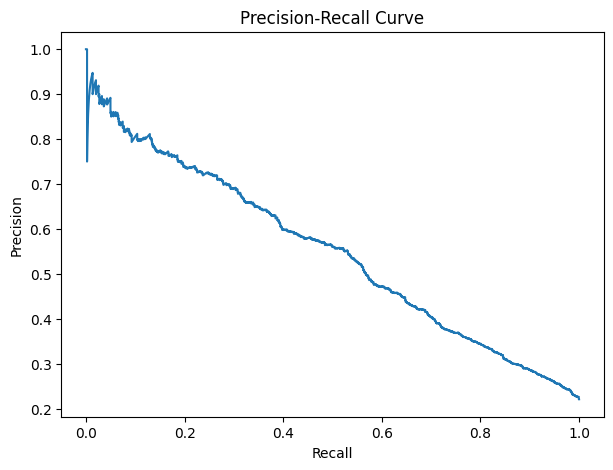

In [22]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.savefig(
    "images/precision_recall_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [23]:
feature_importance.head(10)

,Feature,Importance
5,PAY_0,0.146423
26,AVG_DELAY,0.115975
6,PAY_2,0.066003
24,TOTAL_PAY,0.046251
0,LIMIT_BAL,0.042371
7,PAY_3,0.040262
25,PAY_RATIO,0.038250
23,TOTAL_BILL,0.037849
11,BILL_AMT1,0.037499
17,PAY_AMT1,0.033849


In [24]:
print("AUC Score:", roc_auc)

AUC Score: 0.7746179651869814


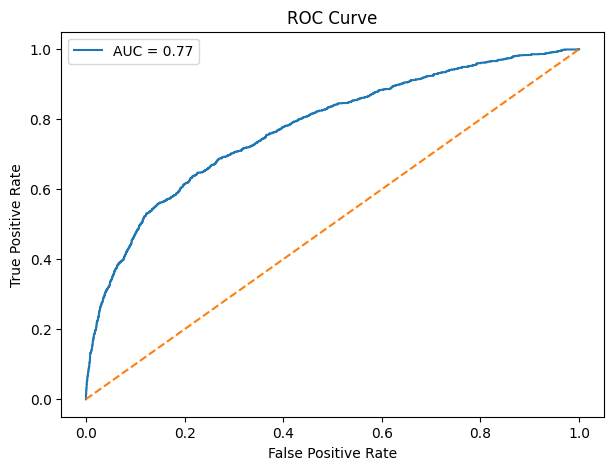

In [25]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_final.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "images/roc_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

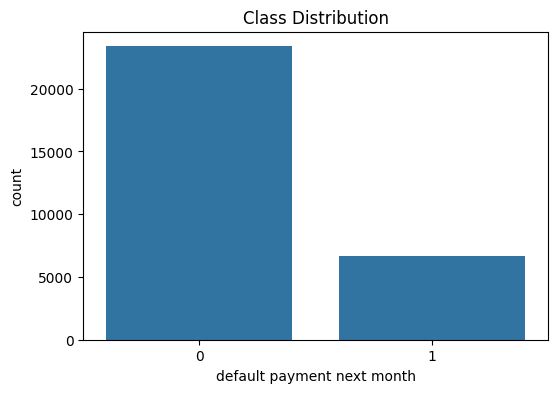

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='default payment next month',
    data=df
)

plt.title("Class Distribution")

plt.savefig(
    "images/class_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

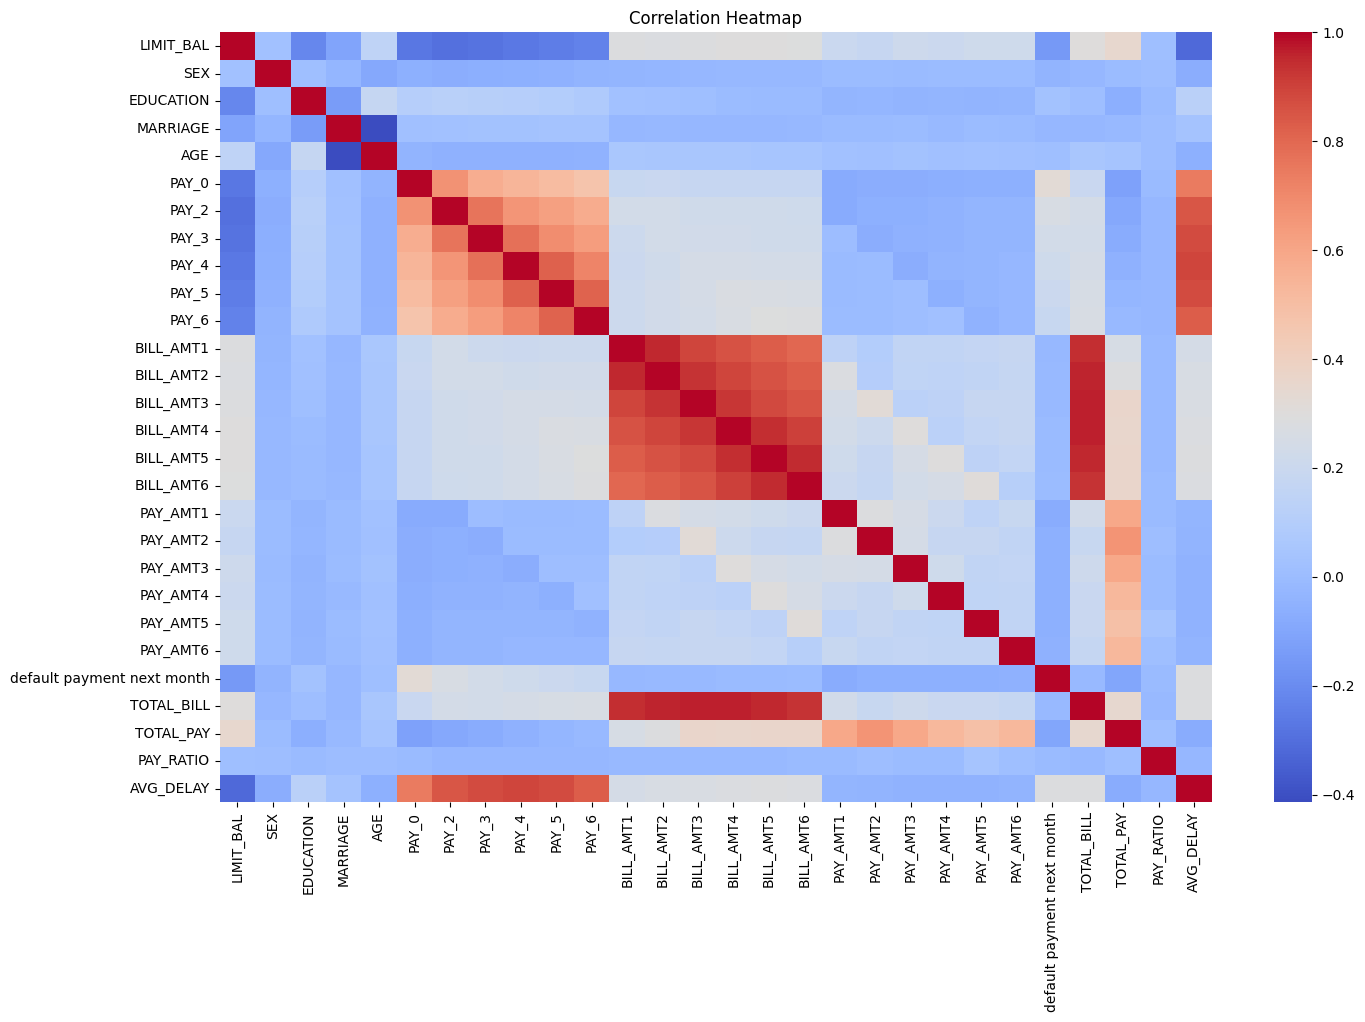

In [27]:
plt.figure(figsize=(16,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig(
    "images/correlation_heatmap_final.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

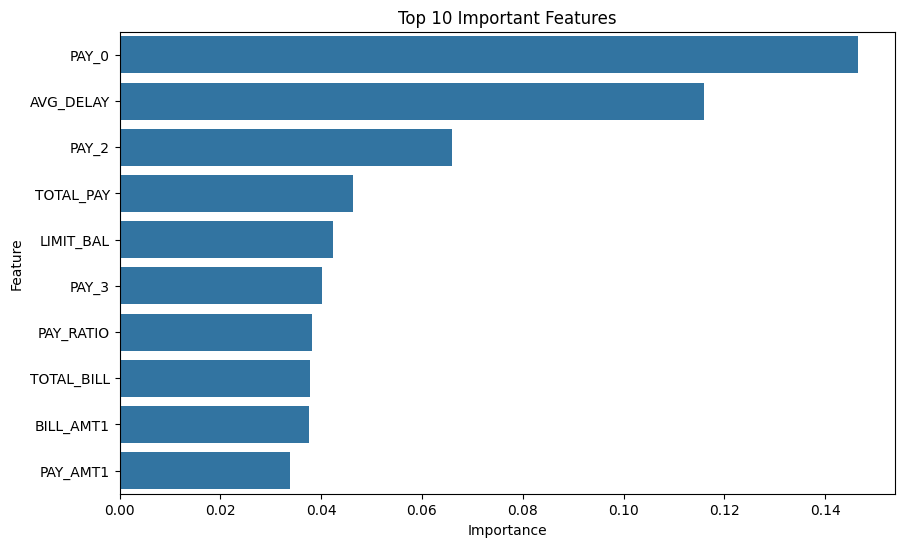

In [28]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_final.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)

plt.title("Top 10 Important Features")

plt.savefig(
    "images/top10_features_final.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

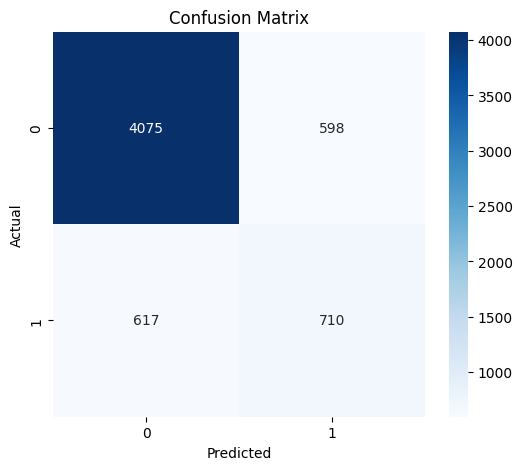

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "images/confusion_matrix_final.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

y_pred_final = rf_final.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_final))

print(classification_report(y_test, y_pred_final))

Accuracy: 0.7975
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4673
           1       0.54      0.54      0.54      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.70      0.70      6000
weighted avg       0.80      0.80      0.80      6000



In [31]:
rf_weighted = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_weighted.fit(X_train, y_train)

y_pred_weighted = rf_weighted.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_weighted))
print(classification_report(y_test, y_pred_weighted))

Accuracy: 0.7875
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.52      0.56      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000



In [32]:
X = df.drop("default payment next month", axis=1)
y = df["default payment next month"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
df["TOTAL_BILL"] = (
    df["BILL_AMT1"] + df["BILL_AMT2"] + df["BILL_AMT3"] +
    df["BILL_AMT4"] + df["BILL_AMT5"] + df["BILL_AMT6"]
)

df["TOTAL_PAY"] = (
    df["PAY_AMT1"] + df["PAY_AMT2"] + df["PAY_AMT3"] +
    df["PAY_AMT4"] + df["PAY_AMT5"] + df["PAY_AMT6"]
)

df["PAY_RATIO"] = df["TOTAL_PAY"] / (df["TOTAL_BILL"] + 1)

df["AVG_DELAY"] = (
    df["PAY_0"] + df["PAY_2"] + df["PAY_3"] +
    df["PAY_4"] + df["PAY_5"] + df["PAY_6"]
) / 6

In [34]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.812
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
X = df.drop("default payment next month", axis=1)
y = df["default payment next month"]

In [38]:
df = df.drop("ID", axis=1)

df.head()

KeyError: "['ID'] not found in axis"

In [ ]:
import pandas as pd

df = pd.read_excel(
    "data/default of credit card clients.xls",
    header=1
)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
import os

os.listdir()

['data', 'final_project.ipynb', 'images', 'proje.ipynb']

In [ ]:
df = pd.read_excel(
    "default of credit card clients.xls",
    header=1
)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'default of credit card clients.xls'

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import cross_val_score